Using deterministic seed: 42
Artifacts will be saved to: /content/lob_project_outputs

Market sample:
   t         mid    return       ofi  toxicity  rolling_vol
0  0  100.000000  0.000000  0.000000  0.000000     0.000000
1  1   99.973235 -0.026765  0.304717  0.593898     0.013383
2  2  100.012935  0.039700  1.009461  1.000000     0.027305
3  3   99.961900 -0.051035 -1.092994  1.000000     0.033668
4  4   99.942442 -0.019458 -0.801204  0.656653     0.030375

Simulation sample:
   t  decision_t         mid       ofi  toxicity  bid_quote  ask_quote  \
0  0           0  100.000000  0.000000  0.000000      99.95     100.05   
1  1           0   99.973235  0.304717  0.593898      99.95     100.05   
2  2           0  100.012935  1.009461  1.000000      99.95     100.05   
3  3           1   99.961900 -1.092994  1.000000      99.90     100.05   
4  4           2   99.942442 -0.801204  0.656653      99.92     100.11   

   reservation_price  half_spread  bid_fill  ...  bid_fill_price  \
0    

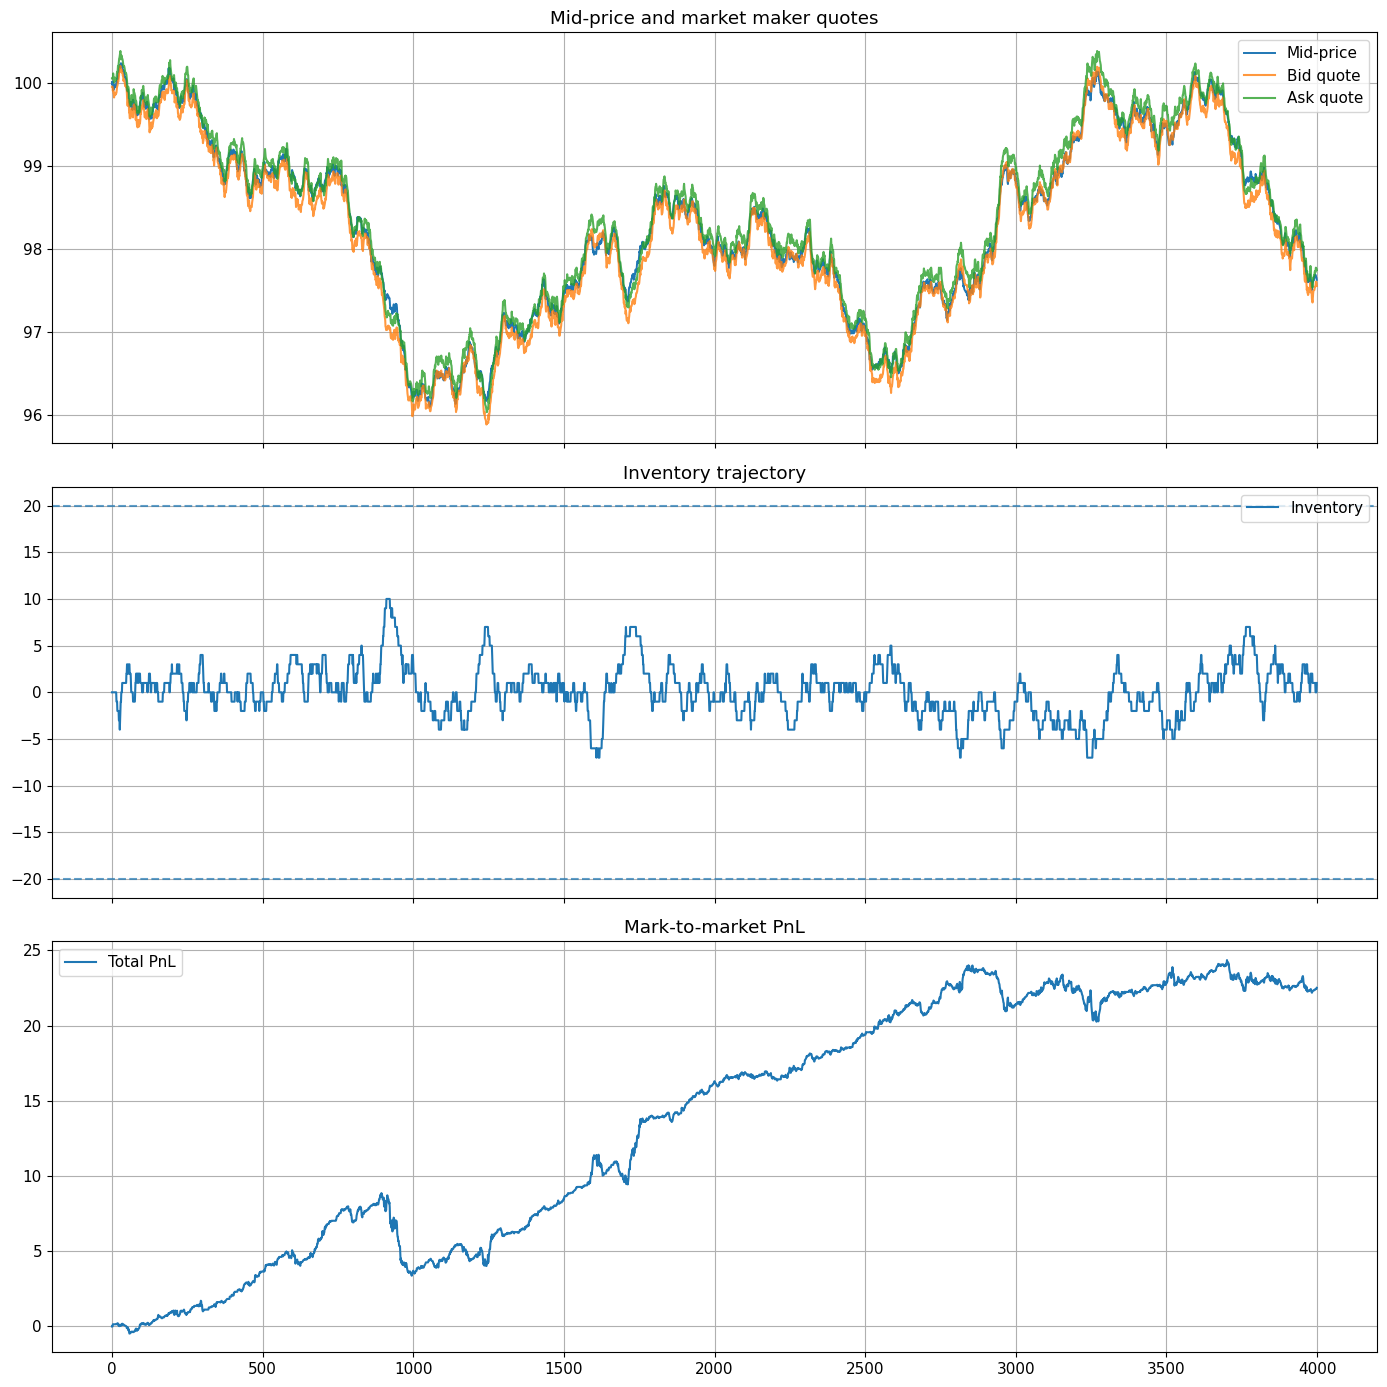

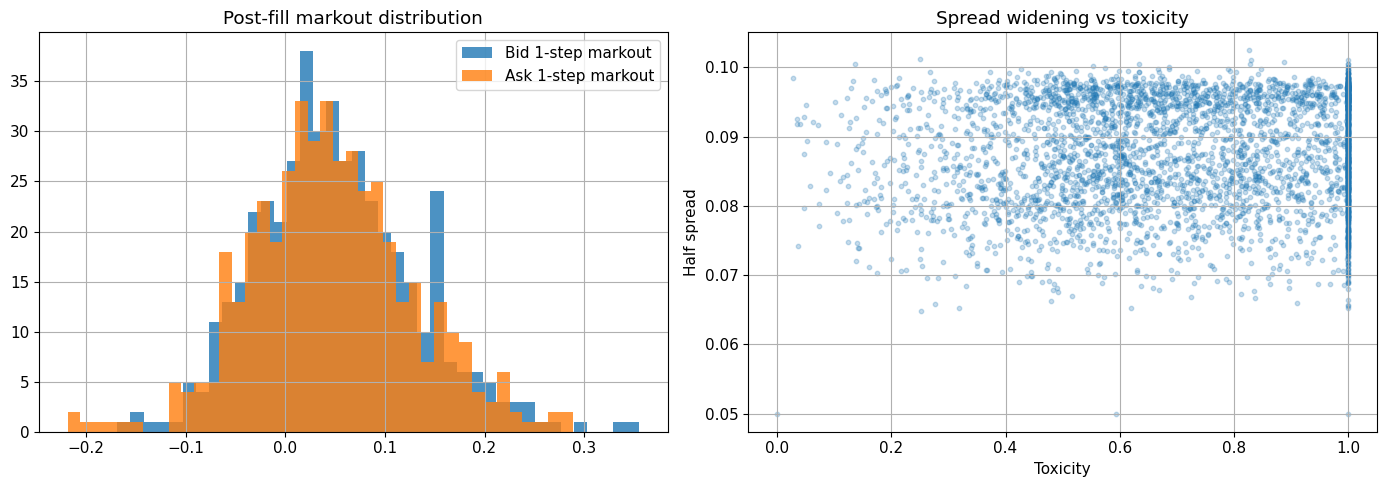


Summary table:
               metric       value
0           final_pnl   22.507432
1     mean_pnl_change    0.005627
2             pnl_std    0.094226
3         sharpe_like    0.059717
4        max_drawdown   -5.478991
5   avg_abs_inventory    2.019750
6       inventory_std    2.694568
7     total_bid_fills  452.000000
8     total_ask_fills  451.000000
9         total_fills  903.000000
10  avg_bid_markout_1    0.051847
11  avg_ask_markout_1    0.046155
12  cum_slippage_cost    1.806000
13    avg_half_spread    0.087747


In [1]:
import math
import json
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY AND OUTPUT SETUP
# ============================================================
SEED = 42
rng = np.random.default_rng(SEED)

OUTPUT_DIR = Path("lob_project_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print(f"Using deterministic seed: {SEED}")
print(f"Artifacts will be saved to: {OUTPUT_DIR.resolve()}")


# ============================================================
# 2. CONFIGURATION
# ============================================================
@dataclass
class MarketConfig:
    n_steps: int = 4000
    dt: float = 1.0
    init_mid: float = 100.0
    sigma: float = 0.03
    ofi_strength: float = 0.015
    tick_size: float = 0.01


@dataclass
class StrategyConfig:
    base_half_spread: float = 0.05
    inventory_skew: float = 0.02
    max_inventory: int = 20
    order_size: int = 1
    gamma_risk: float = 0.003
    vol_lookback: int = 50
    latency_steps: int = 2
    toxicity_widening: float = 0.03


@dataclass
class FillModelConfig:
    base_fill_prob: float = 0.22
    distance_decay: float = 18.0
    toxicity_sensitivity: float = 0.18
    slippage_per_fill: float = 0.002


@dataclass
class SimulationConfig:
    market: MarketConfig
    strategy: StrategyConfig
    fill: FillModelConfig


config = SimulationConfig(
    market=MarketConfig(),
    strategy=StrategyConfig(),
    fill=FillModelConfig()
)


# ============================================================
# 3. UTILITY FUNCTIONS
# ============================================================
def round_to_tick(price: float, tick_size: float) -> float:
    return round(price / tick_size) * tick_size


def rolling_vol(series: np.ndarray, lookback: int) -> np.ndarray:
    out = np.zeros_like(series)
    for i in range(len(series)):
        start = max(0, i - lookback + 1)
        window = series[start:i+1]
        out[i] = np.std(window) if len(window) > 1 else 0.0
    return out


def sharpe_ratio(returns: np.ndarray, annualization_factor: float = 1.0) -> float:
    std = np.std(returns)
    if std < 1e-12:
        return 0.0
    return float((np.mean(returns) / std) * math.sqrt(annualization_factor))


def max_drawdown(equity_curve: np.ndarray) -> float:
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = equity_curve - running_max
    return float(drawdown.min())


def ensure_serializable(x):
    if isinstance(x, dict):
        return {k: ensure_serializable(v) for k, v in x.items()}
    if isinstance(x, list):
        return [ensure_serializable(v) for v in x]
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, np.generic):
        return x.item()
    return x


# ============================================================
# 4. SYNTHETIC MARKET GENERATION
# ============================================================
def generate_market_path(cfg: MarketConfig, rng: np.random.Generator) -> pd.DataFrame:
    """
    Generate a synthetic market path with:
    - mid-price
    - returns
    - order flow imbalance (OFI)
    - toxicity proxy
    """
    n = cfg.n_steps
    mid = np.zeros(n)
    ret = np.zeros(n)
    ofi = np.zeros(n)
    toxicity = np.zeros(n)

    mid[0] = cfg.init_mid

    for t in range(1, n):
        # OFI is persistent but noisy
        ofi[t] = 0.85 * ofi[t-1] + rng.normal(0, 1.0)

        # Short-horizon drift from order flow
        drift = cfg.ofi_strength * np.tanh(ofi[t])

        # Diffusive shock
        shock = rng.normal(0, cfg.sigma)

        ret[t] = drift + shock
        mid[t] = max(cfg.tick_size, mid[t-1] + ret[t])

        # Toxicity: higher when directional OFI and return align
        toxicity[t] = min(
            1.0,
            0.5 * abs(np.tanh(ofi[t])) + 0.5 * abs(np.sign(ofi[t]) * ret[t] / max(cfg.sigma, 1e-9))
        )

    df = pd.DataFrame({
        "t": np.arange(n),
        "mid": mid,
        "return": ret,
        "ofi": ofi,
        "toxicity": toxicity
    })
    df["rolling_vol"] = rolling_vol(df["return"].values, lookback=config.strategy.vol_lookback)
    return df


market_df = generate_market_path(config.market, rng)
print("\nMarket sample:")
print(market_df.head())


# ============================================================
# 5. QUOTING MODEL
# ============================================================
@dataclass
class QuoteState:
    bid: float
    ask: float
    reservation_price: float
    half_spread: float


def compute_quotes(
    t: int,
    market_df: pd.DataFrame,
    inventory: int,
    cfg: SimulationConfig
) -> QuoteState:
    """
    Inventory-aware quoting logic.
    """
    mid = float(market_df.loc[t, "mid"])
    vol = float(market_df.loc[t, "rolling_vol"])
    toxicity = float(market_df.loc[t, "toxicity"])

    # Reservation price shifts away from inventory
    reservation_price = mid - cfg.strategy.gamma_risk * inventory * max(vol, 0.01) * 100.0
    reservation_price -= cfg.strategy.inventory_skew * inventory

    # Spread widens under vol and toxicity
    half_spread = (
        cfg.strategy.base_half_spread
        + 0.5 * vol
        + cfg.strategy.toxicity_widening * toxicity
    )

    bid = round_to_tick(reservation_price - half_spread, cfg.market.tick_size)
    ask = round_to_tick(reservation_price + half_spread, cfg.market.tick_size)

    ask = max(ask, bid + cfg.market.tick_size)

    return QuoteState(
        bid=bid,
        ask=ask,
        reservation_price=reservation_price,
        half_spread=half_spread
    )


# ============================================================
# 6. FILL MODEL
# ============================================================
def fill_probability(
    side: str,
    quote_price: float,
    mid: float,
    ofi: float,
    toxicity: float,
    cfg: FillModelConfig
) -> float:
    """
    Fill probability decreases with quote distance, but adverse selection creates asymmetry.
    """
    distance = abs(quote_price - mid)
    p = cfg.base_fill_prob * math.exp(-cfg.distance_decay * distance)

    directional_push = np.tanh(ofi)

    if side == "ask":
        p += cfg.toxicity_sensitivity * toxicity * max(directional_push, 0.0)
    elif side == "bid":
        p += cfg.toxicity_sensitivity * toxicity * max(-directional_push, 0.0)

    return float(min(max(p, 0.0), 0.95))


# ============================================================
# 7. MAIN SIMULATION ENGINE
# ============================================================
def run_market_making_simulation(
    cfg: SimulationConfig,
    market_df: pd.DataFrame,
    rng: np.random.Generator
) -> pd.DataFrame:
    """
    Run event-driven market making simulation with:
    - stale quoting due to latency
    - bid/ask fills
    - inventory and cash bookkeeping
    - mark-to-market PnL
    """
    n = len(market_df)
    records = []

    inventory = 0
    cash = 0.0
    cumulative_slippage = 0.0

    for t in range(n):
        # Latency: quote based on stale state
        decision_t = max(0, t - cfg.strategy.latency_steps)

        quote_state = compute_quotes(decision_t, market_df, inventory, cfg)

        current_mid = float(market_df.loc[t, "mid"])
        current_ofi = float(market_df.loc[t, "ofi"])
        current_toxicity = float(market_df.loc[t, "toxicity"])

        bid_fill = 0
        ask_fill = 0
        bid_fill_price = np.nan
        ask_fill_price = np.nan

        # Bid fill: buy inventory
        if inventory < cfg.strategy.max_inventory:
            p_bid = fill_probability(
                side="bid",
                quote_price=quote_state.bid,
                mid=current_mid,
                ofi=current_ofi,
                toxicity=current_toxicity,
                cfg=cfg.fill
            )
            if rng.random() < p_bid:
                bid_fill = cfg.strategy.order_size
                bid_fill_price = quote_state.bid
                inventory += bid_fill
                cash -= bid_fill * (quote_state.bid + cfg.fill.slippage_per_fill)
                cumulative_slippage += bid_fill * cfg.fill.slippage_per_fill

        # Ask fill: sell inventory
        if inventory > -cfg.strategy.max_inventory:
            p_ask = fill_probability(
                side="ask",
                quote_price=quote_state.ask,
                mid=current_mid,
                ofi=current_ofi,
                toxicity=current_toxicity,
                cfg=cfg.fill
            )
            if rng.random() < p_ask:
                ask_fill = cfg.strategy.order_size
                ask_fill_price = quote_state.ask
                inventory -= ask_fill
                cash += ask_fill * (quote_state.ask - cfg.fill.slippage_per_fill)
                cumulative_slippage += ask_fill * cfg.fill.slippage_per_fill

        mtm_value = inventory * current_mid
        total_pnl = cash + mtm_value

        records.append({
            "t": t,
            "decision_t": decision_t,
            "mid": current_mid,
            "ofi": current_ofi,
            "toxicity": current_toxicity,
            "bid_quote": quote_state.bid,
            "ask_quote": quote_state.ask,
            "reservation_price": quote_state.reservation_price,
            "half_spread": quote_state.half_spread,
            "bid_fill": bid_fill,
            "ask_fill": ask_fill,
            "bid_fill_price": bid_fill_price,
            "ask_fill_price": ask_fill_price,
            "inventory": inventory,
            "cash": cash,
            "mtm_value": mtm_value,
            "total_pnl": total_pnl,
            "cum_slippage_cost": cumulative_slippage
        })

    sim_df = pd.DataFrame(records)
    sim_df["pnl_change"] = sim_df["total_pnl"].diff().fillna(0.0)

    # 1-step post-fill markout as adverse-selection diagnostic
    sim_df["bid_markout_1"] = np.where(
        sim_df["bid_fill"] > 0,
        sim_df["mid"].shift(-1) - sim_df["bid_fill_price"],
        np.nan
    )
    sim_df["ask_markout_1"] = np.where(
        sim_df["ask_fill"] > 0,
        sim_df["ask_fill_price"] - sim_df["mid"].shift(-1),
        np.nan
    )

    return sim_df


sim_df = run_market_making_simulation(config, market_df, rng)
print("\nSimulation sample:")
print(sim_df.head())


# ============================================================
# 8. METRICS
# ============================================================
def compute_simulation_metrics(sim_df: pd.DataFrame) -> dict:
    bid_fills = int(sim_df["bid_fill"].sum())
    ask_fills = int(sim_df["ask_fill"].sum())
    total_fills = bid_fills + ask_fills

    pnl_series = sim_df["total_pnl"].values
    pnl_change = sim_df["pnl_change"].values

    bid_markout = sim_df["bid_markout_1"].dropna()
    ask_markout = sim_df["ask_markout_1"].dropna()

    metrics = {
        "final_pnl": float(sim_df["total_pnl"].iloc[-1]),
        "mean_pnl_change": float(np.mean(pnl_change)),
        "pnl_std": float(np.std(pnl_change)),
        "sharpe_like": float(sharpe_ratio(pnl_change)),
        "max_drawdown": float(max_drawdown(pnl_series)),
        "avg_abs_inventory": float(np.mean(np.abs(sim_df["inventory"]))),
        "inventory_std": float(np.std(sim_df["inventory"])),
        "total_bid_fills": bid_fills,
        "total_ask_fills": ask_fills,
        "total_fills": total_fills,
        "avg_bid_markout_1": float(bid_markout.mean()) if len(bid_markout) else np.nan,
        "avg_ask_markout_1": float(ask_markout.mean()) if len(ask_markout) else np.nan,
        "cum_slippage_cost": float(sim_df["cum_slippage_cost"].iloc[-1]),
        "avg_half_spread": float(sim_df["half_spread"].mean())
    }
    return metrics


metrics = compute_simulation_metrics(sim_df)
print("\n=== LOB PROJECT METRICS ===")
for k, v in metrics.items():
    print(f"{k:25s}: {v}")


# ============================================================
# 9. SAVE OUTPUTS
# ============================================================
sim_df.to_csv(OUTPUT_DIR / "lob_simulation_timeseries.csv", index=False)

with open(OUTPUT_DIR / "lob_metrics.json", "w") as f:
    json.dump(ensure_serializable(metrics), f, indent=2)

print("\nSaved files:")
print("-", OUTPUT_DIR / "lob_simulation_timeseries.csv")
print("-", OUTPUT_DIR / "lob_metrics.json")


# ============================================================
# 10. PLOTS
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

axes[0].plot(sim_df["t"], sim_df["mid"], label="Mid-price", linewidth=1.4)
axes[0].plot(sim_df["t"], sim_df["bid_quote"], label="Bid quote", alpha=0.8)
axes[0].plot(sim_df["t"], sim_df["ask_quote"], label="Ask quote", alpha=0.8)
axes[0].set_title("Mid-price and market maker quotes")
axes[0].legend()

axes[1].plot(sim_df["t"], sim_df["inventory"], label="Inventory")
axes[1].axhline(config.strategy.max_inventory, linestyle="--", alpha=0.7)
axes[1].axhline(-config.strategy.max_inventory, linestyle="--", alpha=0.7)
axes[1].set_title("Inventory trajectory")
axes[1].legend()

axes[2].plot(sim_df["t"], sim_df["total_pnl"], label="Total PnL")
axes[2].set_title("Mark-to-market PnL")
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lob_main_plots.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bid_markout = sim_df["bid_markout_1"].dropna()
ask_markout = sim_df["ask_markout_1"].dropna()

axes[0].hist(bid_markout, bins=40, alpha=0.8, label="Bid 1-step markout")
axes[0].hist(ask_markout, bins=40, alpha=0.8, label="Ask 1-step markout")
axes[0].set_title("Post-fill markout distribution")
axes[0].legend()

axes[1].scatter(sim_df["toxicity"], sim_df["half_spread"], alpha=0.25, s=10)
axes[1].set_title("Spread widening vs toxicity")
axes[1].set_xlabel("Toxicity")
axes[1].set_ylabel("Half spread")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lob_microstructure_diagnostics.png", dpi=160)
plt.show()


# ============================================================
# 11. SUMMARY TABLE
# ============================================================
summary_df = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})
print("\nSummary table:")
print(summary_df)